In [1]:
import gc
gc.collect()

import torch
torch.cuda.empty_cache()  # Safe to call even on CPU

In [2]:
import pandas as pd

df = pd.read_csv('return_predictability_data.csv')
df.shape

/var/folders/mn/p97zg4190kl_grdrb5c91h7m0000gn/T/ipykernel_24709/1032643601.py:3: DtypeWarning: Columns (98) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('return_predictability_data.csv')


(4089924, 107)

In [4]:
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

realestate    3013381
rd_sale       2657364
rd_mve        2631975
stdcf         2489634
stdacc        2489634
               ...   
retvol           3449
mvel1            2983
baspread          634
maxret            554
indmom             24
Length: 94, dtype: int64

In [5]:
df['RET_clean'] = pd.to_numeric(df['RET'], errors='coerce')

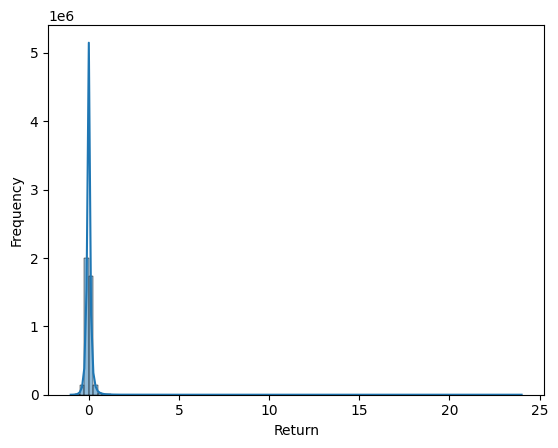

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['RET_clean'], bins=100, kde=True)
plt.xlabel('Return')
plt.ylabel('Frequency')
plt.show()

In [8]:
correlations = df.corr(numeric_only=True)['RET_clean'].sort_values()
print("Top Negative Correlations:\n", correlations.head(10))
print("\nTop Positive Correlations:\n", correlations.tail(10))

Top Negative Correlations:
 macro_svar   -0.113729
mom36m       -0.019619
dolvol       -0.019271
invest       -0.017468
hire         -0.017340
chcsho       -0.016459
grltnoa      -0.016211
egr          -0.015936
lgr          -0.015840
sgr          -0.015478
Name: RET_clean, dtype: float64

Top Positive Correlations:
 maxret       0.012348
retvol       0.018068
ill          0.021454
macro_ep     0.022427
macro_dfy    0.022735
sp           0.024985
baspread     0.025430
agr          0.026220
rd_mve       0.029766
RET_clean    1.000000
Name: RET_clean, dtype: float64


In [10]:
correlations.to_clipboard()

In [11]:
non_features = ['permo', 'DATE', 'name', 'RET', 'RET_clean']

feature_cols = [col for col in df.columns if col not in non_features]

In [12]:
for col in feature_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [13]:
df[feature_cols] = df[feature_cols].fillna(df[feature_cols].median())

In [14]:
from sklearn.preprocessing import StandardScaler

scalar = StandardScaler()
df[feature_cols] = scalar.fit_transform(df[feature_cols])

In [16]:
from sklearn.model_selection import train_test_split

df['DATE'] = pd.to_datetime(df['DATE'])

train_split = df['DATE'].quantile(0.6)
val_split = df['DATE'].quantile(0.8)

train_df = df[df['DATE'] <= train_split]
val_df = df[(df['DATE'] > train_split) & (df['DATE'] <= val_split)]
test_df = df[df['DATE'] > val_split]

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(2456624, 108)
(818668, 108)
(814632, 108)


In [17]:
X_train = train_df[feature_cols]
y_train = train_df['RET_clean']

X_val = val_df[feature_cols]
y_val = val_df['RET_clean']

X_test = test_df[feature_cols]
y_test = test_df['RET_clean']

In [18]:
# For Training Already Done:
X_train_clean = X_train[y_train.notnull()]
y_train_clean = y_train[y_train.notnull()]

# For Validation
X_val_clean = X_val[X_val.notnull().all(axis=1)]
y_val_clean = y_val[X_val.notnull().all(axis=1)]

# For Test
X_test_clean = X_test[X_test.notnull().all(axis=1)]
y_test_clean = y_test[X_test.notnull().all(axis=1)]

In [19]:
# Mask for Validation
val_mask = X_val.notnull().all(axis=1) & y_val.notnull()
X_val_clean = X_val[val_mask]
y_val_clean = y_val[val_mask]

# Mask for Test
test_mask = X_test.notnull().all(axis=1) & y_test.notnull()
X_test_clean = X_test[test_mask]
y_test_clean = y_test[test_mask]


In [20]:
def compute_portfolio_returns(df, prediction_column):
    # For each month, get top 100 predicted stocks
    monthly_returns = []

    for date, group in df.groupby('DATE'):
        top100 = group.sort_values(by=prediction_column, ascending=False).head(100)
        avg_return = top100['RET_clean'].mean()
        monthly_returns.append(avg_return)

    return pd.Series(monthly_returns, name=f"portfolio_return_{prediction_column}")


In [21]:
def evaluate_model_top100(test_df, pred_column):
    monthly_returns = []

    for date, group in test_df.groupby('DATE'):
        top100 = group.sort_values(by=pred_column, ascending=False).head(100)
        avg_return = top100['RET_clean'].mean()
        monthly_returns.append(avg_return)

    model_series = pd.Series(monthly_returns, name=f"Top100_{pred_column}")

    # Portfolio stats
    mean_ret = model_series.mean()
    volatility = model_series.std()
    sharpe = mean_ret / volatility

    return {
        "avg_return": mean_ret,
        "volatility": volatility,
        "sharpe": sharpe,
        "monthly_returns": model_series
    }


In [22]:
def evaluate_portfolio(returns):
    mean_ret = returns.mean()
    volatility = returns.std()
    sharpe = mean_ret / volatility
    return mean_ret, volatility, sharpe


In [24]:
from sklearn.linear_model import Lasso

best_params = {
    'alpha': 0.001682603228232911,
    'fit_intercept': False,
    'max_iter': 10000,
    'selection': 'random',
    'tol': 0.000111182
}

ls = Lasso(
    alpha=best_params['alpha'],
    fit_intercept=best_params['fit_intercept'],
    selection=best_params['selection'],
    tol=best_params['tol'],
    max_iter=10000
)

ls.fit(X_train_clean, y_train_clean)


Lasso(alpha=0.001682603228232911, fit_intercept=False, max_iter=10000,
      selection='random', tol=0.000111182)

In [29]:
selected_indices = ls.coef_ !=0
feature_names = X_train_clean.columns
selected_features = feature_names[selected_indices]
print(selected_features)

Index(['chmom', 'dolvol', 'mom1m', 'mom12m', 'agr', 'orgcap', 'rd_mve', 'sp',
       'tang', 'baspread', 'ill', 'retvol', 'zerotrade', 'macro_ntis',
       'macro_tms', 'macro_dfy', 'macro_svar'],
      dtype='object')


In [36]:
import xgboost as xgb

dtrain = xgb.DMatrix(X_train_clean[selected_features], label=y_train_clean)
dval = xgb.DMatrix(X_val_clean[selected_features], label=y_val_clean)
dtest = xgb.DMatrix(X_test_clean[selected_features], label=y_test_clean)

In [37]:
from sklearn.metrics import r2_score, mean_squared_error

def objective(trial):
    params = {
        'objective': 'reg:squarederror',
        'tree_method': 'hist',
        'eval_metric': 'rmse',
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'eta': trial.suggest_float('eta', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'lambda': trial.suggest_float('lambda', 1e-3, 10.0, log=True),
        'alpha': trial.suggest_float('alpha', 1e-3, 10.0, log=True)
    }

    booster = xgb.train(
        params,
        dtrain,
        num_boost_round=1000,
        evals=[(dval, 'val')],
        early_stopping_rounds=50,
        verbose_eval=False
    )

    preds = booster.predict(dval)
    return r2_score(y_val_clean, preds)


In [38]:
import optuna

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print("Best Params:", study.best_params)

[I 2025-05-13 12:15:57,862] A new study created in memory with name: no-name-69ff5c1b-5ca7-45e0-b684-a493848aa901


[I 2025-05-13 12:16:01,525] Trial 0 finished with value: -0.024120203446849953 and parameters: {'max_depth': 7, 'eta': 0.06629041557835422, 'subsample': 0.8034287518755809, 'colsample_bytree': 0.7641715194119396, 'lambda': 2.428440364587837, 'alpha': 0.006502506741519195}. Best is trial 0 with value: -0.024120203446849953.
[I 2025-05-13 12:16:04,849] Trial 1 finished with value: -0.037765246102134276 and parameters: {'max_depth': 9, 'eta': 0.0871601338080934, 'subsample': 0.587040876559554, 'colsample_bytree': 0.7921514618838843, 'lambda': 0.14501130116785643, 'alpha': 6.475311410649107}. Best is trial 0 with value: -0.024120203446849953.
[I 2025-05-13 12:16:07,048] Trial 2 finished with value: -0.02408016416744263 and parameters: {'max_depth': 7, 'eta': 0.06266150256336134, 'subsample': 0.9495954979196668, 'colsample_bytree': 0.6221991048604287, 'lambda': 1.3039706632622168, 'alpha': 0.0021907803242079815}. Best is trial 2 with value: -0.02408016416744263.
[I 2025-05-13 12:16:09,224] 

Best Params: {'max_depth': 4, 'eta': 0.013593298680339181, 'subsample': 0.7893148293673695, 'colsample_bytree': 0.6617970741963524, 'lambda': 0.08542874772640183, 'alpha': 0.0011218789331581716}


In [39]:
best_params = {'max_depth': 4, 'eta': 0.013593298680339181, 'subsample': 0.7893148293673695, 'colsample_bytree': 0.6617970741963524, 'lambda': 0.08542874772640183, 'alpha': 0.0011218789331581716}

xgb_opt = xgb.train(
    best_params,
    dtrain,
    num_boost_round=1000,
    evals=[(dval, 'val')],
    early_stopping_rounds=50,
    verbose_eval=100
)

[0]	val-rmse:0.18833
[77]	val-rmse:0.18812


In [41]:
from sklearn.metrics import r2_score, mean_squared_error

print("Validation R2:", r2_score(y_val_clean, xgb_opt.predict(dval)))
print("Test R2:", r2_score(y_test_clean, xgb_opt.predict(dtest)))
print("Test MSE:", mean_squared_error(y_test_clean, xgb_opt.predict(dtest)))

Validation R2: 0.0012301688667814004
Test R2: 0.004954582771798166
Test MSE: 0.027633180683648464


In [43]:
test_df_clean = test_df.loc[X_test_clean.index].copy()
test_df_clean['LS_pred'] = ls.predict(X_test_clean)
test_df_clean['xgb_pred'] = xgb_opt.predict(dtest)

In [44]:
ls_returns = compute_portfolio_returns(test_df_clean, 'LS_pred')
xgb_returns = compute_portfolio_returns(test_df_clean, 'xgb_pred')

In [46]:
xgb_stats = evaluate_portfolio(xgb_returns)
ls_stats = evaluate_portfolio(ls_returns)

print(f"Avg Return: {xgb_stats[0]:.4f} | Volatility: {xgb_stats[1]:.4f} | Sharpe: {xgb_stats[2]:.4f}")
print(f"Avg Return: {ls_stats[0]:.4f} | Volatility: {ls_stats[1]:.4f} | Sharpe: {ls_stats[2]:.4f}")



Avg Return: 0.0318 | Volatility: 0.1251 | Sharpe: 0.2542
Avg Return: 0.0240 | Volatility: 0.1023 | Sharpe: 0.2350


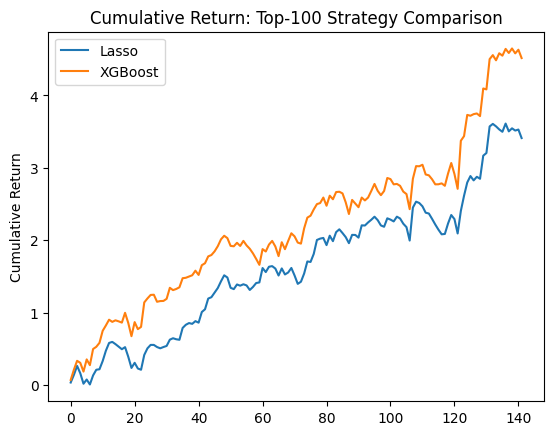

In [45]:
(ls_returns.cumsum()).plot(label='Lasso')
(xgb_returns.cumsum()).plot(label='XGBoost')
plt.legend()
plt.title("Cumulative Return: Top-100 Strategy Comparison")
plt.ylabel("Cumulative Return")
plt.show()


In [47]:
import xgboost as xgb

dtrain = xgb.DMatrix(X_train_clean, label=y_train_clean)
dval = xgb.DMatrix(X_val_clean, label=y_val_clean)
dtest = xgb.DMatrix(X_test_clean, label=y_test_clean)

In [48]:
from sklearn.metrics import r2_score, mean_squared_error

def objective(trial):
    params = {
        'objective': 'reg:squarederror',
        'tree_method': 'hist',
        'eval_metric': 'rmse',
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'eta': trial.suggest_float('eta', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'lambda': trial.suggest_float('lambda', 1e-3, 10.0, log=True),
        'alpha': trial.suggest_float('alpha', 1e-3, 10.0, log=True)
    }

    booster = xgb.train(
        params,
        dtrain,
        num_boost_round=1000,
        evals=[(dval, 'val')],
        early_stopping_rounds=50,
        verbose_eval=False
    )

    preds = booster.predict(dval)
    return r2_score(y_val_clean, preds)


In [49]:
import optuna

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print("Best Params:", study.best_params)

[I 2025-05-13 12:45:01,858] A new study created in memory with name: no-name-206ae01c-6efb-4cc1-8689-d40f14109096
[I 2025-05-13 12:45:27,119] Trial 0 finished with value: -0.09093730049625659 and parameters: {'max_depth': 5, 'eta': 0.0959007252363619, 'subsample': 0.769061331102264, 'colsample_bytree': 0.9235566567043911, 'lambda': 0.007768320243362636, 'alpha': 0.003508556378594816}. Best is trial 0 with value: -0.09093730049625659.
[I 2025-05-13 12:45:39,050] Trial 1 finished with value: -1.357449257852497 and parameters: {'max_depth': 9, 'eta': 0.2909101315786822, 'subsample': 0.6624105381274666, 'colsample_bytree': 0.8945947112265409, 'lambda': 0.0043659918528630385, 'alpha': 1.2357545377920338}. Best is trial 0 with value: -0.09093730049625659.
[I 2025-05-13 12:45:43,992] Trial 2 finished with value: -0.0897381333110121 and parameters: {'max_depth': 4, 'eta': 0.13983131458265866, 'subsample': 0.9255374987010399, 'colsample_bytree': 0.5197941308312923, 'lambda': 0.10513671709011065

Best Params: {'max_depth': 3, 'eta': 0.010349055727106116, 'subsample': 0.8707346091219851, 'colsample_bytree': 0.8637472095517803, 'lambda': 4.913265434822595, 'alpha': 0.002684830106588274}


In [50]:
best_params = {'max_depth': 3, 'eta': 0.010349055727106116, 'subsample': 0.8707346091219851, 'colsample_bytree': 0.8637472095517803, 'lambda': 4.913265434822595, 'alpha': 0.002684830106588274}

xgb_full = xgb.train(
    best_params,
    dtrain,
    num_boost_round=1000,
    evals=[(dval, 'val')],
    early_stopping_rounds=50,
    verbose_eval=100
)

[0]	val-rmse:0.18831
[100]	val-rmse:0.18805
[115]	val-rmse:0.18810


In [51]:
test_df_clean['xgb_full_pred'] = xgb_full.predict(dtest)

In [ ]:
xgb_full_returns = compute_portfolio_returns(test_df_clean, 'xgb_full_pred')
xgb_full_stats = evaluate_portfolio(xgb_full_returns)

print(f"Avg Return: {xgb_stats[0]:.4f} | Volatility: {xgb_stats[1]:.4f} | Sharpe: {xgb_stats[2]:.4f}")
print(f"Avg Return: {ls_stats[0]:.4f} | Volatility: {ls_stats[1]:.4f} | Sharpe: {ls_stats[2]:.4f}")
print(f"Avg Return: {xgb_full_stats[0]:.4f} | Volatility: {xgb_full_stats[1]:.4f} | Sharpe: {xgb_full_stats[2]:.4f}")


Avg Return: 0.0305 | Volatility: 0.1106 | Sharpe: 0.2760


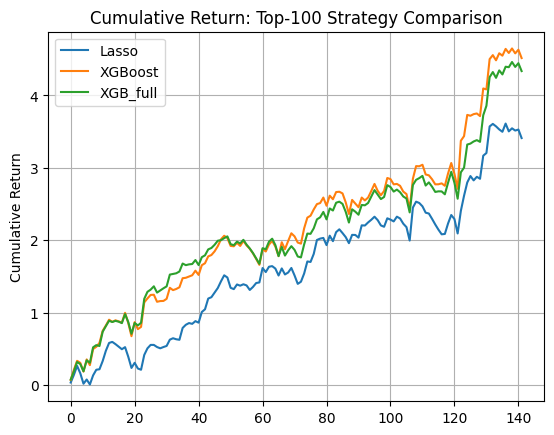

In [56]:
(ls_returns.cumsum()).plot(label='Lasso')
(xgb_returns.cumsum()).plot(label='XGBoost')
(xgb_full_returns.cumsum()).plot(label='XGB_full')
plt.legend()
plt.grid(True)
plt.title("Cumulative Return: Top-100 Strategy Comparison")
plt.ylabel("Cumulative Return")
plt.show()


In [54]:
print(f"Avg Return: {xgb_stats[0]:.4f} | Volatility: {xgb_stats[1]:.4f} | Sharpe: {xgb_stats[2]:.4f}")
print(f"Avg Return: {ls_stats[0]:.4f} | Volatility: {ls_stats[1]:.4f} | Sharpe: {ls_stats[2]:.4f}")
print(f"Avg Return: {xgb_full_stats[0]:.4f} | Volatility: {xgb_full_stats[1]:.4f} | Sharpe: {xgb_full_stats[2]:.4f}")


Avg Return: 0.0318 | Volatility: 0.1251 | Sharpe: 0.2542
Avg Return: 0.0240 | Volatility: 0.1023 | Sharpe: 0.2350
Avg Return: 0.0305 | Volatility: 0.1106 | Sharpe: 0.2760


In [55]:
from sklearn.metrics import r2_score, mean_squared_error

print("Validation R2:", r2_score(y_val_clean, xgb_full.predict(dval)))
print("Test R2:", r2_score(y_test_clean, xgb_full.predict(dtest)))
print("Test MSE:", mean_squared_error(y_test_clean, xgb_full.predict(dtest)))

Validation R2: 0.0016366563191497763
Test R2: 0.018026067164534254
Test MSE: 0.027270175454164422


In [ ]:
0.004954582771798166